Reading Images...
image1 loaded successfully, shape: (169, 299, 3)
image2 loaded successfully, shape: (148, 152, 3)
image3 loaded successfully, shape: (148, 220, 3)
Reshaping Images...
Enter clusters for 3 images (e.g., 3 3 3): 2 3 4 
Clustering...
Creating Segmented Images...
Segmented Image 1


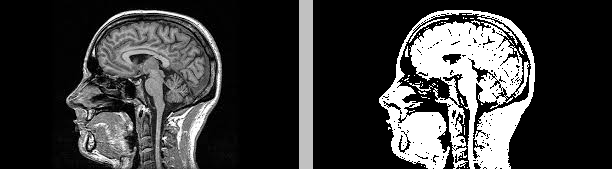

Segmented Image 2


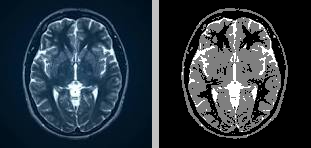

Segmented Image 3


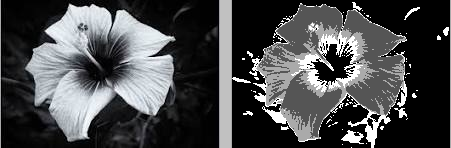

Saving results...
Saved: output_1_C2.png
Saved: output_2_C3.png
Saved: output_3_C4.png
Program executed successfully ✅


In [5]:

import numpy as np
from sklearn.cluster import KMeans
import cv2
from google.colab.patches import cv2_imshow
import datetime

print("Reading Images...")
image1 = cv2.imread("/content/f1.jpeg")
image2 = cv2.imread("/content/f2.jpeg")
image3 = cv2.imread("/content/f3.jpeg")
images = [image1, image2, image3]

for i, img in enumerate(images, start=1):
    if img is None:
        print(f"Error: image{i} not found! Make sure it is uploaded.")
        exit()
    else:
        print(f"image{i} loaded successfully, shape: {img.shape}")

for i in range(3):
    max_dim = 512
    h, w = images[i].shape[:2]
    if max(h, w) > max_dim:
        scale = max_dim / max(h, w)
        new_size = (int(w*scale), int(h*scale))
        images[i] = cv2.resize(images[i], new_size)
        print(f"image{i+1} resized to {new_size} for faster processing.")

print("Reshaping Images...")
reshaped = [img.reshape((-1,3)) for img in images]

numClusters = list(map(int, input("Enter clusters for 3 images (e.g., 3 3 3): ").split()))
if len(numClusters) != 3:
    print("Please enter exactly 3 numbers!")
    # The original exit() call did not prevent the rest of the script from running in this context.
    # The subsequent code will now only run if the input is valid.
else:
    print("Clustering...")
    clustering = []
    for i in range(3):
        kmeans = KMeans(n_clusters=numClusters[i], n_init=10, max_iter=300, random_state=42)
        kmeans.fit(reshaped[i])
        clustering.append(kmeans.labels_.reshape(images[i].shape[0], images[i].shape[1]))

    sortedLabels = [sorted(range(numClusters[i]), key=lambda x: -np.sum(clustering[i]==x)) for i in range(3)]

    print("Creating Segmented Images...")
    concatImages = []

    for j in range(3):
        KNNImage = np.zeros(images[j].shape[:2], dtype=np.uint8)
        for i, label in enumerate(sortedLabels[j]):
            if numClusters[j] - 1 == 0:
                # If there's only one cluster, set all pixels in KNNImage to a uniform value (e.g., 0)
                KNNImage[clustering[j] == label] = 0
            else:
                KNNImage[clustering[j] == label] = int(255/(numClusters[j]-1))*i

        separator = 193*np.ones((images[j].shape[0], int(0.05*images[j].shape[1]),3), dtype=np.uint8)
        concat = np.concatenate((images[j], separator, cv2.cvtColor(KNNImage, cv2.COLOR_GRAY2BGR)), axis=1)
        concatImages.append(concat)

    for i, img in enumerate(concatImages, start=1):
        print(f"Segmented Image {i}")
        cv2_imshow(img)

    print("Saving results...")
    for i, img in enumerate(concatImages, start=1):
        fname = f"output_{i}_C{numClusters[i-1]}.png"
        cv2.imwrite(fname, img)
        print(f"Saved: {fname}")

    print("Program executed successfully ✅")